<a href="https://colab.research.google.com/github/Deaderikaw/Jobsheet-Pengolahan-Citra_Dea-Derika-Winahyu_IK-3D/blob/main/Jobsheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **JOBSHEET 04: SEGMENTASI GAMBAR**

# 1. Segmentasi Menggunakan Thresholding Global dan Otsu

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

In [ ]:
# Memuat citra (coins sudah grayscale)
image_coins = data.coins()

In [ ]:
# Tentukan nilai ambang manual
thresh_manual = 100
binary_manual = image_coins > thresh_manual

In [ ]:
# Menggunakan metode Otsu (otomatis)
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

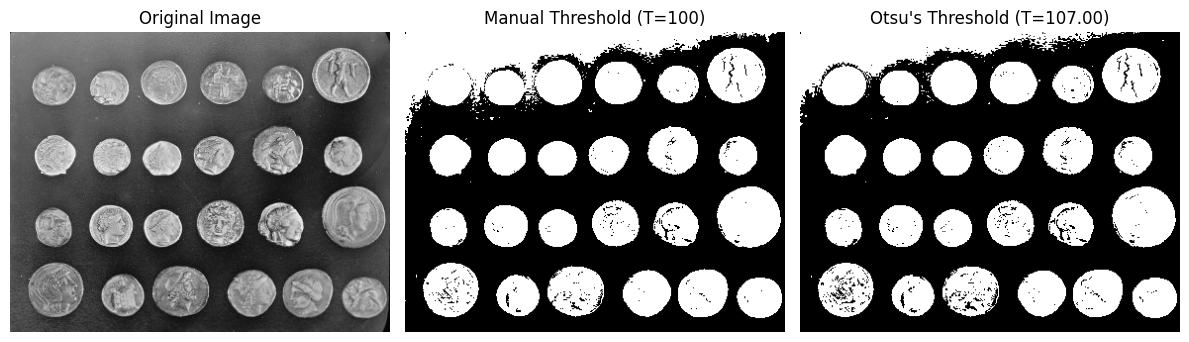

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Threshold manual
ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

# Threshold Otsu
ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

Nilai threshold Otsu yang ditemukan: 107


# Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

In [ ]:
# Memuat citra (grayscale)
image_camera = data.camera()

In [ ]:
# Titik awal (seed) untuk region growing
seed_point = (50, 150)

In [ ]:
# Flood fill dengan toleransi intensitas
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

In [ ]:
# Tandai area hasil segmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

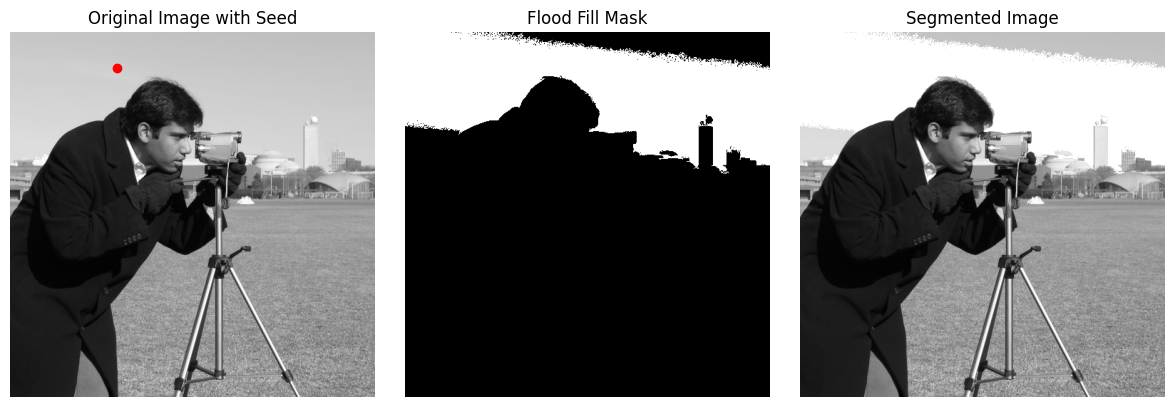

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli + seed
ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

# Mask hasil flood
ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

In [ ]:
# Memuat citra berwarna (astronaut)
image_astro = data.astronaut()

# Konversi ke float [0..1]
image_astro_float = image_astro.astype(float) / 255.0

In [ ]:
# Konversi RGB ke Lab
image_lab = rgb2lab(image_astro_float)

# Ubah ke bentuk array [jumlah_piksel, fitur]
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

In [ ]:
# Tentukan jumlah cluster
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Hilangkan warning
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

In [ ]:
# Ubah label ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

In [ ]:
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

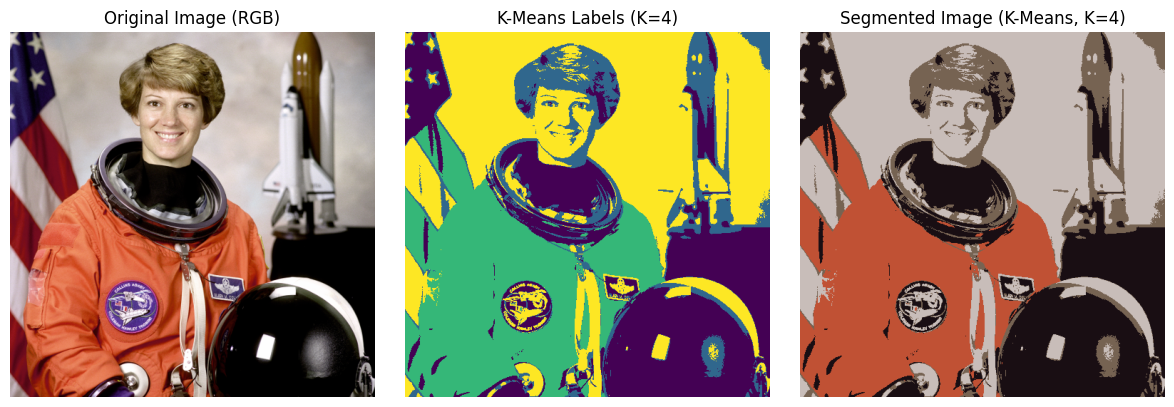

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Label cluster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Hasil segmentasi
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

In [ ]:
# Memuat citra grayscale (coins)
image_coins = data.coins()

In [ ]:
# Menghitung gradien sebagai representasi topografi
elevation_map = filters.sobel(image_coins)

In [ ]:
# Inisialisasi marker
markers = np.zeros_like(image_coins)

# Marker latar belakang
markers[image_coins < 30] = 1

# Marker objek (koin)
markers[image_coins > 150] = 2

In [ ]:
# Terapkan algoritma watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

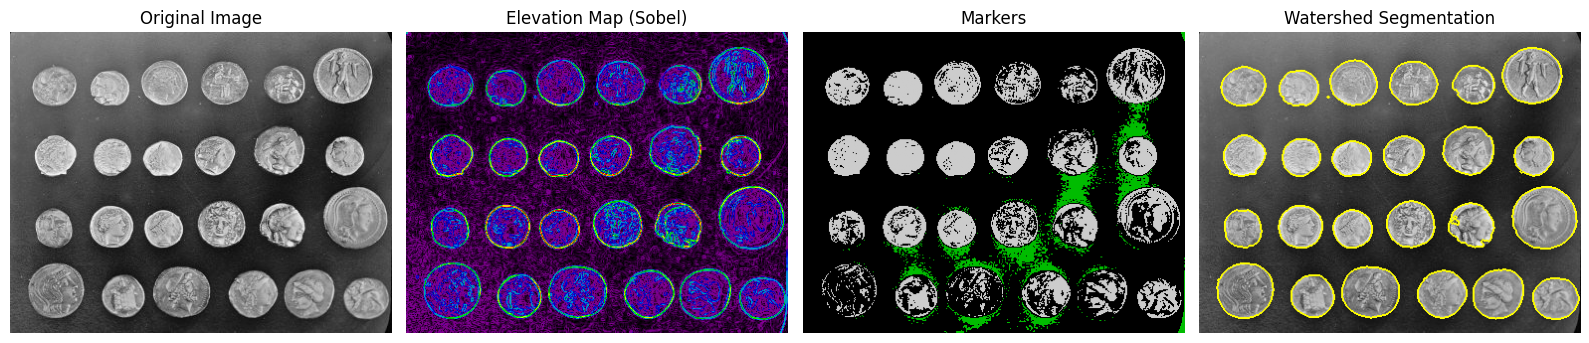

In [ ]:
# Tandai batas segmentasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Gambar asli
ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Elevation map
ax[1].imshow(elevation_map, cmap='nipy_spectral')
ax[1].set_title('Elevation Map (Sobel)')
ax[1].axis('off')

# Marker
ax[2].imshow(markers, cmap='nipy_spectral')
ax[2].set_title('Markers')
ax[2].axis('off')

# Hasil watershed
ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

# Praktikum 5. Perbandingan Visual Hasil Segmentasi

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

In [ ]:
# Memuat citra grayscale
image = data.camera()
image_float = img_as_float(image)

In [ ]:
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

In [ ]:
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

In [ ]:
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

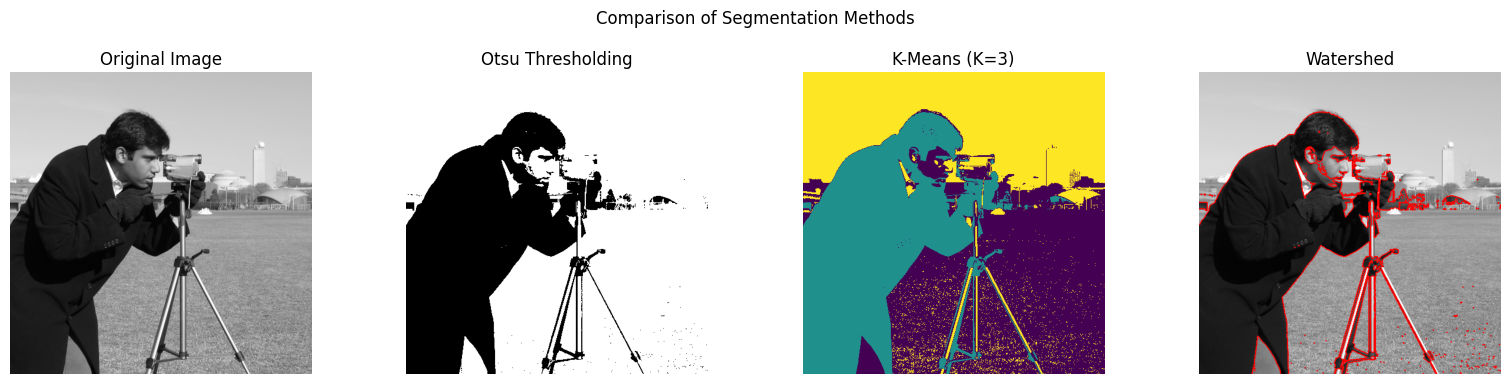

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Original
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

# Otsu
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Watershed
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0)
)

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **TUGAS**

# Eksperimen Thresholding: Terapkan metode thresholding Otsu pada citra data page(). Apakah hasilnya memuaskan? Mengapa? Coba gunakan metode thresholding lain yang ada di skimage.filters (misalnya, threshold_local atau threshold_yen) dan bandingkan hasilnya.

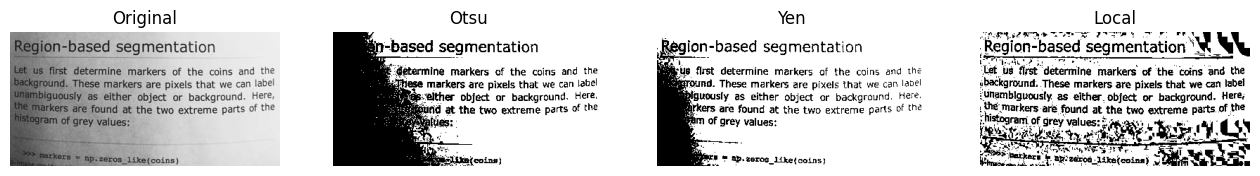

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# Load gambar
image = data.page()

# Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# Threshold Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# Threshold Local (Adaptive)
binary_local = filters.threshold_local(image, block_size=35)
binary_local = image > binary_local

# Visualisasi
fig, ax = plt.subplots(1, 4, figsize=(16,4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original")

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu")

ax[2].imshow(binary_yen, cmap='gray')
ax[2].set_title("Yen")

ax[3].imshow(binary_local, cmap='gray')
ax[3].set_title("Local")

for a in ax:
    a.axis('off')

plt.show()

# Cari satu contoh citra sederhana dari internet (misalnya, citra buah-buahan dengan latar belakang polos, atau citra sel mikroskop). Terapkan setidaknya tiga metode segmentasi yang berbeda (misalnya, Otsu, K-Means, dan Watershed) pada citra tersebut. Bandingkan hasilnya secara visual dan diskusikan metode mana yang paling cocok untuk citra pilihan Anda, serta jelaskan alasannya

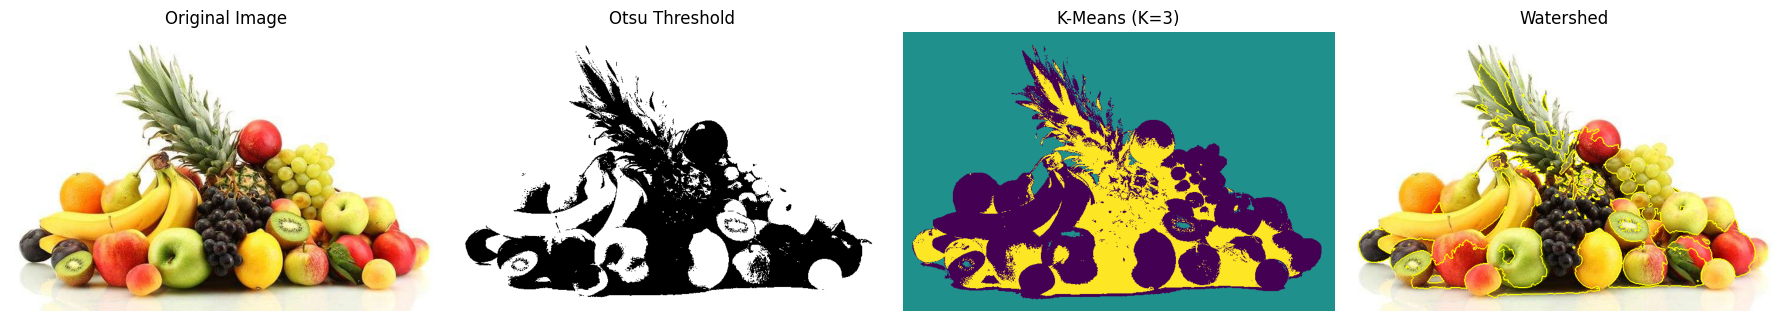

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import warnings

# ================================
# 1. LOAD GAMBAR DARI GOOGLE DRIVE
# ================================
image = io.imread('/content/drive/MyDrive/Colab Notebooks/citra buah.jpeg')

# Konversi ke float dan grayscale
image_float = img_as_float(image)
gray = color.rgb2gray(image)

# ================================
# 2. OTSU THRESHOLDING
# ================================
thresh_otsu = filters.threshold_otsu(gray)
binary_otsu = gray > thresh_otsu

# ================================
# 3. K-MEANS CLUSTERING
# ================================
rows, cols, ch = image.shape
pixel_values = image.reshape((-1, 3))

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    labels = kmeans.fit_predict(pixel_values)

segmented_kmeans = labels.reshape(rows, cols)

# ================================
# 4. WATERSHED SEGMENTATION
# ================================
# Gradient sebagai "topografi"
gradient = filters.sobel(gray)

# Marker HARUS integer
markers = np.zeros_like(gray, dtype=np.int32)

# Atur marker (bisa disesuaikan tergantung gambar)
markers[gray < 0.3] = 1   # background
markers[gray > 0.7] = 2   # objek terang

# Terapkan watershed
watershed = segmentation.watershed(gradient, markers)

# Tampilkan boundary biar lebih jelas
watershed_boundary = segmentation.mark_boundaries(image_float, watershed)

# ================================
# 5. VISUALISASI
# ================================
fig, ax = plt.subplots(1, 4, figsize=(18,5))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu Threshold")
ax[1].axis('off')

ax[2].imshow(segmented_kmeans, cmap='viridis')
ax[2].set_title("K-Means (K=3)")
ax[2].axis('off')

ax[3].imshow(watershed_boundary)
ax[3].set_title("Watershed")
ax[3].axis('off')

plt.tight_layout()
plt.show()